In [ ]:
from typing import Annotated

import mlflow
from langchain_core.messages import AIMessage, AnyMessage, HumanMessage
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict

# Enabling tracing for LangGraph (LangChain)
mlflow.langchain.autolog()

# Optional: Set a tracking URI and an experiment
mlflow.set_tracking_uri("http://localhost:5001")
mlflow.set_experiment("LangGraph")

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

/Users/eshantdas/Desktop/SelfStudy/PersonalTest/MLFlow/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o")


def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

llm_with_tools = llm.bind_tools([multiply])

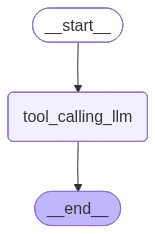

In [3]:
from IPython.display import Image, display
from langgraph.graph import END, START, StateGraph


# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
messages = graph.invoke({"messages": HumanMessage(content="Hello!")})

Trace(trace_id=tr-40c0e8f4c5bd6582cb3c3b6de4dd3e0d)

## Full Agent

In [2]:

from IPython.display import Image, display
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition


def one_node(state: MessagesState):
    pass

def blog_model():
    # Graph
    builder = StateGraph(MessagesState)

    # Define nodes: these do the work

    builder.add_node("one_node",one_node)
    # Define edges: these determine how the control flow moves
    builder.add_edge(START, "one_node")
    builder.add_edge("one_node", END)
    react_graph = builder.compile()
    messages = react_graph.invoke({"messages": []})
    return messages  

In [3]:
from langchain_openai import ChatOpenAI

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b


def generate_text_for_blog(content:str)->str:
    """
    Advance Agent for generating blog for a content
    """
    a=blog_model()
    return f"Best Blog This is the content {a}"
    

tools = [add, multiply, divide,generate_text_for_blog]
llm = ChatOpenAI(model="gpt-4o")


llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)

In [4]:

from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

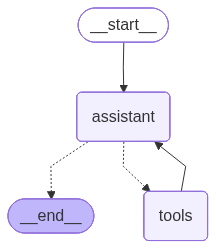

In [6]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [8]:
messages = [HumanMessage(content="Generate a blog content for Holi")]
messages = react_graph.invoke({"messages": messages})

Trace(trace_id=tr-0473de5c2f1b6ffb32e3b0431b99a008)